In [1]:
# =======================
# 1. Imports
# =======================
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor

In [2]:
# ============================
# 2. Load datasets
# =============================
train_df = pd.read_csv(r'C:\Users\sheri\Desktop\machinlearning\data\processed_data\feature_engineered_train.csv')
eval_df = pd.read_csv(r'C:\Users\sheri\Desktop\machinlearning\data\processed_data\featured_engineered_eval.csv')

In [3]:
# =============================
# 4. Define target & features
# ==============================
target = "AEP_MW"
X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_eval = eval_df.drop(columns=[target])
y_eval = eval_df[target]

print("Train Shape:", X_train.shape)
print("Eval Shape:", X_eval.shape)

Train Shape: (62920, 4)
Eval Shape: (34923, 4)


In [4]:
# ==============================================
# 4. Train a GradientBoosting Regressor
# ==============================================
gradboostReg_model = GradientBoostingRegressor(
    n_estimators=500,
    random_state=42,
    )

gradboostReg_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [5]:
# ===================================
# 5. Evaluate performance
# ===================================
y_pred = gradboostReg_model.predict(X_eval)

mae = mean_absolute_error(y_eval, y_pred)
rmse = np.sqrt(mean_absolute_error(y_eval, y_pred))
#rmse1 = np.sqrt(mae)
r2 = r2_score(y_eval, y_pred)


print("GradientBoostingRegressor Performance:")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
#print(f"RMSE1: {rmse1:,.2f}")
print(f"R2: {r2:,.4f}")

GradientBoostingRegressor Performance:
MAE: 1,365.24
RMSE: 36.95
R2: 0.5051


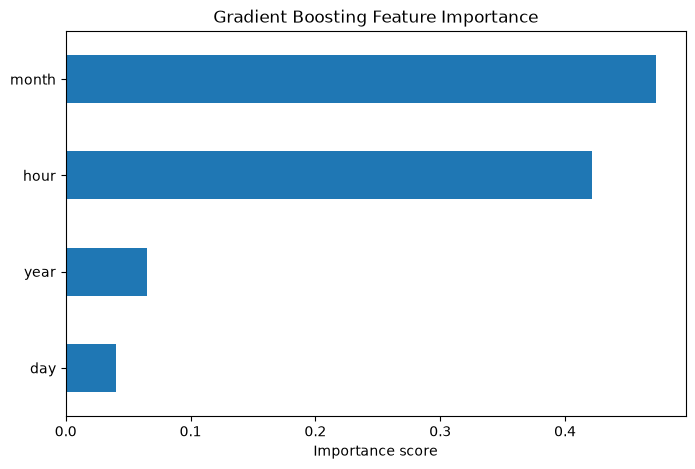

In [6]:
# Plot importances
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance
importance = pd.Series(
    gradboostReg_model.feature_importances_,
    index=X_train.columns
)

# Sort values
importance = importance.sort_values(ascending=False)

# Plot top features
importance.head().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance score")
plt.gca().invert_yaxis()
plt.show()